<a href="https://colab.research.google.com/github/sumshun-nahar-eity/Phitron_Artificial_Intelligence_ML_Course/blob/main/Sumshun_nahar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database


In [4]:
!pip install -q gradio scikit-learn pandas numpy matplotlib seaborn


Data Loading (5 Marks)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import warnings
import gradio as gr
warnings.filterwarnings('ignore')


Data Preprocessing (10 Marks)

In [5]:
import os
df = pd.read_csv(os.path.join(path, 'diabetes.csv'))

print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nDataset information:")
print(df.info())

print("\nBasic statistics:")
print(df.describe())

print("\nColumn names:")
print(df.columns.tolist())

print("\nTarget variable 'Outcome' found:",
      'Outcome' in df.columns)



First 5 rows of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape:
(768, 9)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnan

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


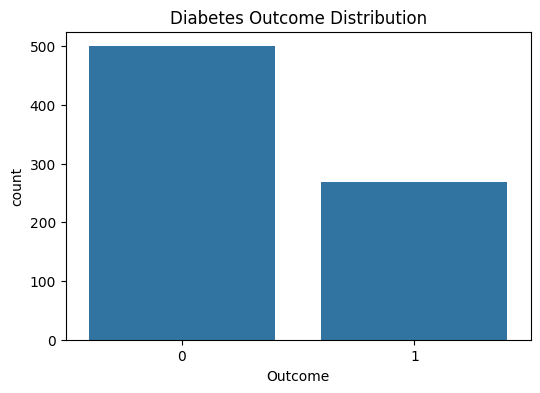

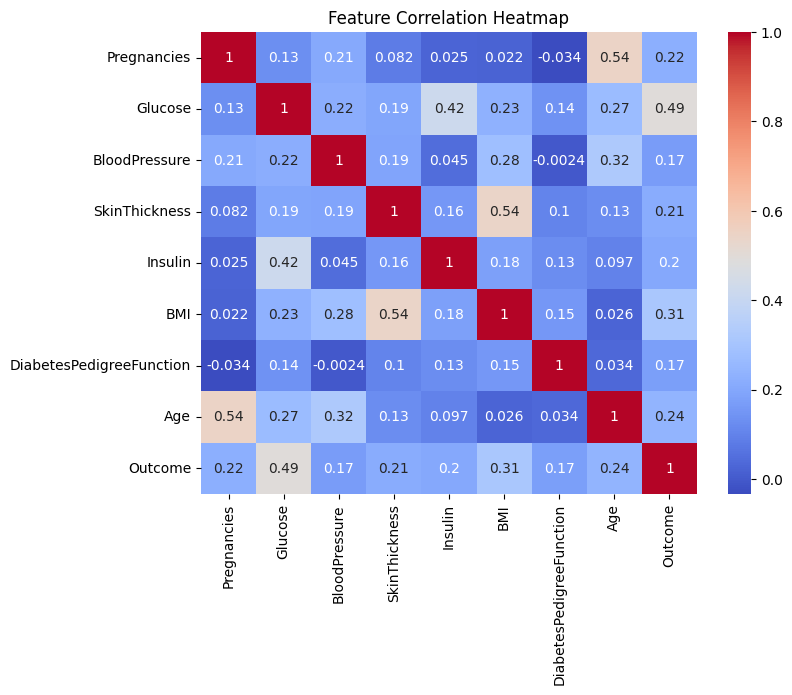


Preprocessing completed!


In [6]:
print("Missing values:")
print(df.isnull().sum())


cols_with_zero = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

df.fillna(df.median(), inplace=True)

plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df)
plt.title('Diabetes Outcome Distribution')
plt.show()


plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

print("\nPreprocessing completed!")





Pipeline Creation (10 Marks)

In [7]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

print("Pipeline created successfully!")


Pipeline created successfully!


Primary Model Selection (5 Marks)

In [8]:
print("SELECTED MODEL: RANDOM FOREST CLASSIFIER")
print("\nJustification:")
print("1. Handles non-linear relationships")
print("2. Robust to noise and outliers")
print("3. Performs well on tabular medical data")
print("4. Provides feature importance")
print("5. Reduces overfitting via ensemble learning")


SELECTED MODEL: RANDOM FOREST CLASSIFIER

Justification:
1. Handles non-linear relationships
2. Robust to noise and outliers
3. Performs well on tabular medical data
4. Provides feature importance
5. Reduces overfitting via ensemble learning


Model Training (10 Marks)

In [9]:
print("Training model...")
pipeline.fit(X_train, y_train)
print("Model training completed!")


Training model...
Model training completed!


Cross-Validation (10 Marks)

In [10]:
cv_scores = cross_val_score(
    pipeline, X_train, y_train,
    cv=5, scoring='accuracy'
)

print("Cross Validation Accuracy Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())


Cross Validation Accuracy Scores: [0.72357724 0.80487805 0.72357724 0.79674797 0.79508197]
Mean Accuracy: 0.7687724910035986
Standard Deviation: 0.03705036927129574


Hyperparameter Tuning (10 Marks)

In [11]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters:
{'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV Accuracy: 0.7753068707157661


Best Model Selection (10 Marks)

In [12]:
best_model = grid_search.best_estimator_
print("Best model selected based on validation accuracy")


Best model selected based on validation accuracy


Model Performance Evaluation (10 Marks)

MODEL PERFORMANCE METRICS
Accuracy : 0.7403
Precision: 0.6522
Recall   : 0.5556
F1 Score : 0.6000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



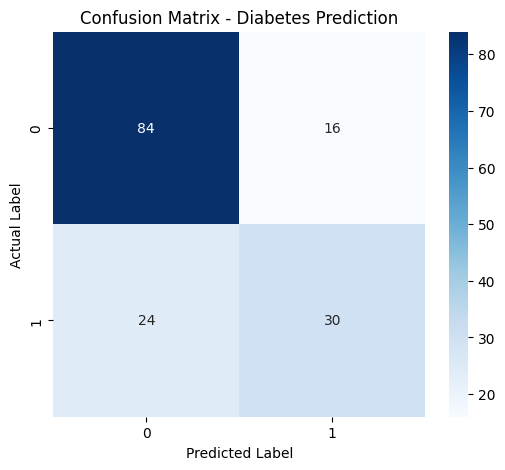

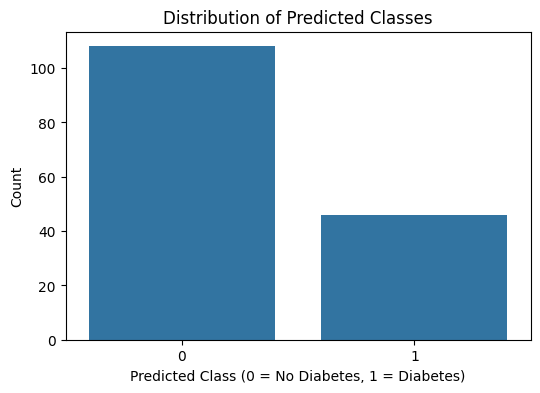

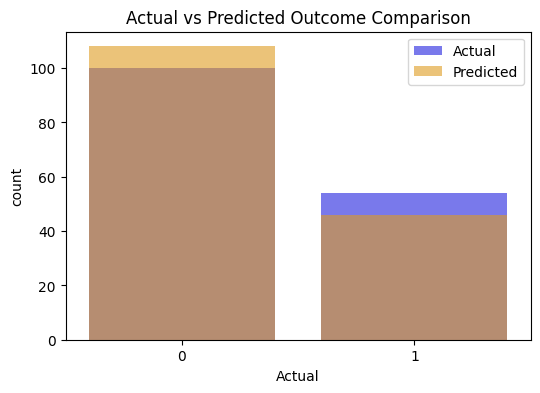


✅ Model Performance Evaluation Completed Successfully!


In [13]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# 1️⃣ Prediction on test data
y_pred = best_model.predict(X_test)

# 2️⃣ Numerical evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL PERFORMANCE METRICS")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("=" * 40)

# 3️⃣ Classification report
print("\nCLASSIFICATION REPORT")
print("=" * 40)
print(classification_report(y_test, y_pred))

# 4️⃣ Confusion Matrix (PICTURE)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Diabetes Prediction")
plt.show()

# 5️⃣ Distribution of predicted classes (PICTURE)
plt.figure(figsize=(6,4))
sns.countplot(x=y_pred)
plt.title("Distribution of Predicted Classes")
plt.xlabel("Predicted Class (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Count")
plt.show()

# 6️⃣ Actual vs Predicted comparison (PICTURE)
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

plt.figure(figsize=(6,4))
sns.countplot(x='Actual', data=comparison_df, color='blue', alpha=0.6, label='Actual')
sns.countplot(x='Predicted', data=comparison_df, color='orange', alpha=0.6, label='Predicted')
plt.title("Actual vs Predicted Outcome Comparison")
plt.legend(['Actual', 'Predicted'])
plt.show()

print("\n✅ Model Performance Evaluation Completed Successfully!")



Web Interface with Gradio (10 Marks)

In [14]:
def predict_diabetes(
    pregnancies, glucose, bp, skin, insulin, bmi, dpf, age
):
    input_df = pd.DataFrame({
        'Pregnancies':[pregnancies],
        'Glucose':[glucose],
        'BloodPressure':[bp],
        'SkinThickness':[skin],
        'Insulin':[insulin],
        'BMI':[bmi],
        'DiabetesPedigreeFunction':[dpf],
        'Age':[age]
    })

    pred = best_model.predict(input_df)[0]
    return "Diabetic" if pred == 1 else "Not Diabetic"

# Move the Gradio interface definition and launch outside the function
iface = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Number(label="Pregnancies"),
        gr.Number(label="Glucose"),
        gr.Number(label="Blood Pressure"),
        gr.Number(label="Skin Thickness"),
        gr.Number(label="Insulin"),
        gr.Number(label="BMI"),
        gr.Number(label="Diabetes Pedigree Function"),
        gr.Number(label="Age")
    ],
    outputs="text",
    title="Diabetes Prediction System",
    description="ML Final Exam Project"
)

iface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7164fde59f3348e532.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Deployment to Hugging Face (10 Marks)

In [17]:
# ===============================
# AUTO CREATE DEPLOYMENT FILES
# ===============================

import joblib
import os

# 1️⃣ Save trained model
joblib.dump(best_model, "diabetes_model.joblib")
print("✅ diabetes_model.joblib created")

# 2️⃣ Create requirements.txt
requirements_content = """gradio>=4.0
pandas>=2.0
numpy>=1.23
scikit-learn>=1.3
joblib>=1.3
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("✅ requirements.txt created")

# 3️⃣ Create app.py
app_code = '''
import gradio as gr
import pandas as pd
import joblib

# Load trained model
model = joblib.load("diabetes_model.joblib")

def predict_diabetes(
    pregnancies, glucose, bp, skin, insulin, bmi, dpf, age
):
    input_df = pd.DataFrame({
        "Pregnancies": [pregnancies],
        "Glucose": [glucose],
        "BloodPressure": [bp],
        "SkinThickness": [skin],
        "Insulin": [insulin],
        "BMI": [bmi],
        "DiabetesPedigreeFunction": [dpf],
        "Age": [age]
    })

    prediction = model.predict(input_df)[0]
    return "Diabetic" if prediction == 1 else "Not Diabetic"

demo = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Number(label="Pregnancies"),
        gr.Number(label="Glucose"),
        gr.Number(label="Blood Pressure"),
        gr.Number(label="Skin Thickness"),
        gr.Number(label="Insulin"),
        gr.Number(label="BMI"),
        gr.Number(label="Diabetes Pedigree Function"),
        gr.Number(label="Age")
    ],
    outputs="text",
    title="Diabetes Prediction System",
    description="ML Final Exam Project"
)

if __name__ == "__main__":
    demo.launch()
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py created")

# 4️⃣ Verify files
print("\n📁 FILES IN CURRENT DIRECTORY:")
print(os.listdir())


✅ diabetes_model.joblib created
✅ requirements.txt created
✅ app.py created

📁 FILES IN CURRENT DIRECTORY:
['.config', '.gradio', 'requirements.txt', 'diabetes_model.joblib', 'app.py', 'sample_data']
